# 03 Peer Support Funnel Analysis

This notebook evaluates the operational funnel for the Diabetes Peer Support intervention.

The main questions are:

1. Among members assigned to Diabetes Peer Support, how many were invited, enrolled, attended at least one session, and attended multiple sessions?
2. Where does drop-off occur in the peer-support funnel?
3. Is higher session attendance associated with higher diabetes testing compliance?

Important caution:

This notebook is operational and exploratory. Session attendance is not randomized. Members who attend sessions may differ from non-attendees in motivation, access, health literacy, transportation, or baseline engagement. Therefore, session attendance should not be interpreted as a causal treatment effect.

### Notebook Scope

This notebook is an operational funnel analysis, not the primary causal treatment-effect analysis.

The formal intent-to-treat A/B test is handled in Notebook 02. This notebook focuses on how members assigned to the Diabetes Peer Support arm moved through the invitation, enrollment, attendance, and session-completion funnel.

Because enrollment and attendance occur after random assignment, these metrics are interpreted as operational engagement outcomes, not randomized treatment effects.

## 1. Imports

In [1]:
from pathlib import Path # Used for project-relative paths.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

## 2. Load Dataset

In [2]:
# Define project root
project_root = Path("..")

# Define data path
data_path = project_root / "data" / "raw" / "mock_diabetes_peer_support_ab_test.csv"

# Load dataset

df = pd.read_csv(data_path)

# Preview first five rows

df.head()

,member_id,age,gender,region,plan_type,target_population_flag,diabetes_severity_score,chronic_condition_count,baseline_engagement_score,health_literacy_score,...,peer_leader_supervised,contact_frequency_per_month,assigned_diabetes_tests_count,a1c_test_completed,kidney_screening_completed,eye_exam_completed,diabetes_tests_completed_count,diabetes_testing_compliance_rate,diabetes_testing_compliant,program_data_quality_issue
0,1,64,Male,Urban,Medicaid,1,0.263,1,0.866,0.349,...,0,1,3,1,1,1,3,1.000,1,0
1,2,69,Male,Rural,D-SNP,1,0.361,5,0.253,0.533,...,1,2,3,1,0,0,1,0.333,0,0
2,3,74,Female,Urban,Medicare Advantage,1,0.598,2,0.483,0.189,...,0,1,3,1,0,0,1,0.333,0,0
3,4,72,Male,Urban,Medicare Advantage,1,0.189,4,0.377,0.811,...,1,2,3,0,1,1,2,0.667,0,0
4,5,42,Female,Suburban,Medicaid,1,0.759,3,0.541,0.606,...,0,1,3,1,1,0,2,0.667,0,0


## 3. Preview Dataset 

In [3]:
# Preview the first rows to confirm the dataset loaded correctly
df.head()

,member_id,age,gender,region,plan_type,target_population_flag,diabetes_severity_score,chronic_condition_count,baseline_engagement_score,health_literacy_score,...,peer_leader_supervised,contact_frequency_per_month,assigned_diabetes_tests_count,a1c_test_completed,kidney_screening_completed,eye_exam_completed,diabetes_tests_completed_count,diabetes_testing_compliance_rate,diabetes_testing_compliant,program_data_quality_issue
0,1,64,Male,Urban,Medicaid,1,0.263,1,0.866,0.349,...,0,1,3,1,1,1,3,1.000,1,0
1,2,69,Male,Rural,D-SNP,1,0.361,5,0.253,0.533,...,1,2,3,1,0,0,1,0.333,0,0
2,3,74,Female,Urban,Medicare Advantage,1,0.598,2,0.483,0.189,...,0,1,3,1,0,0,1,0.333,0,0
3,4,72,Male,Urban,Medicare Advantage,1,0.189,4,0.377,0.811,...,1,2,3,0,1,1,2,0.667,0,0
4,5,42,Female,Suburban,Medicaid,1,0.759,3,0.541,0.606,...,0,1,3,1,1,0,2,0.667,0,0


In [4]:
# Review column names, data types, and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 33 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   member_id                         4000 non-null   int64  
 1   age                               4000 non-null   int64  
 2   gender                            4000 non-null   str    
 3   region                            4000 non-null   str    
 4   plan_type                         4000 non-null   str    
 5   target_population_flag            4000 non-null   int64  
 6   diabetes_severity_score           4000 non-null   float64
 7   chronic_condition_count           4000 non-null   int64  
 8   baseline_engagement_score         3749 non-null   float64
 9   health_literacy_score             3706 non-null   float64
 10  prior_testing_compliance_rate     4000 non-null   float64
 11  sdoh_risk_score                   4000 non-null   float64
 12  food_insecurity  

In [5]:
# Confirm randomized experiment group counts
df["experiment_group"].value_counts()

experiment_group
Diabetes Peer Support    2078
Standard Outreach        1922
Name: count, dtype: int64

## 4. Define Treatment Arm

In [6]:
# Isolate treatment-arm members because the peer-support funnel exists only for this group
treatment = df[df["experiment_group"] == "Diabetes Peer Support"].copy()

# Confirm treatment-arm size
treatment.shape

(2078, 33)

## 5. Funnel Logic Validation

Before analyzing the funnel, we confirm that the peer-support fields follow the expected business rules:

- Standard Outreach members should not be invited 
- Only invited members can enroll.
- Only enrolled members can attend.
- Only attendees should have positive session counts.

Any violation would suggest a data-generation or pipeline issue.

## 6. Funnel Violation Checks

In [7]:
# Check whether any control members were incorrectly marked as invited
control_invited = (
    (df["experiment_group"] == "Standard Outreach") & 
    (df["program_invited"] == 1)
).sum()

# Check whether enrollment occurred without a prior invitation
enrolled_without_invite = (
    (df["program_enrolled"] == 1) &
    (df["program_invited"] == 0)
).sum() 

# Check whether attendance occurred without enrollment
attended_without_enroll = (
    (df["attended_at_least_one_session"] == 1) & 
    (df["program_enrolled"] == 0 )
).sum()

# Check whether positive session counts exist without confirmed attendance 
sessions_without_attendance = (
    (df["sessions_attended_count"] > 0) &
    (df["attended_at_least_one_session"] == 0)
).sum()

# Combine all validation checks into one readable dictionary
violations = {
    "control_invited": control_invited,
    "enrolled_without_invite": enrolled_without_invite,
    "attended_without_enroll": attended_without_enroll,
    "sessions_without_attendance": sessions_without_attendance,
}

violations



{'control_invited': np.int64(0),
 'enrolled_without_invite': np.int64(0),
 'attended_without_enroll': np.int64(0),
 'sessions_without_attendance': np.int64(0)}

## 7. Funnel Validation Interpretation

The expected result is 0 for every violation check.

If all values are 0, the funnel logic is valid:

- Control members were not exposed to the peer-support program.
- Enrollment only occurred after invitation.
- Attendance only occurred after enrollment.
- Positive session counts only occurred for members who attended at least one session.

## 8. Peer Support Funnel Counts

In [8]:
# Total members assigned to Diabetes Peer Support
assigned_count = len(treatment)

# Members invited to the peer-support program
invited_count = treatment["program_invited"].sum()

# Members who enrolled after invitation
enrolled_count = treatment["program_enrolled"].sum()

# Members who attended at least one peer-support session
attended_count = treatment["attended_at_least_one_session"].sum()

# Create funnel count summary table
funnel_summary = pd.DataFrame({
    "funnel_stage": [
        "Assigned to Peer Support",
        "Invited",
        "Enrolled",
        "Attended at Least One Session"
    ],
    "member_count": [
        assigned_count,
        invited_count,
        enrolled_count,
        attended_count
    ]
})

# Calculate each stage as a percentage of all treatment-assigned members
funnel_summary["pct_of_assigned"] = (
    funnel_summary["member_count"] / assigned_count * 100
)

# Display clean summary table
funnel_summary.round(1)

,funnel_stage,member_count,pct_of_assigned
0,Assigned to Peer Support,2078,100.0
1,Invited,1758,84.6
2,Enrolled,765,36.8
3,Attended at Least One Session,280,13.5


### Interpretation

This table shows how many members reached each major peer-support funnel stage.

The denominator for `pct_of_assigned` is all members assigned to the Diabetes Peer Support group. This helps show how much of the original treatment-assigned population remained at each stage of the funnel.

## 9. Peer Support Funnel Rates

In [9]:
funnel_conversion_summary = pd.DataFrame({
    "conversion_step": [
        "Invitation Rate Among Assigned",
        "Enrollment Rate Among Invited",
        "Attendance Rate Among Enrolled",
        "Attendance Rate Among Assigned"
    ],
    "numerator": [
        invited_count,
        enrolled_count,
        attended_count,
        attended_count
    ],
    "denominator": [
        assigned_count,
        invited_count,
        enrolled_count,
        assigned_count
    ]
})

# Calculate conversion rate as a percentage
funnel_conversion_summary["conversion_rate_pct"] = (
    funnel_conversion_summary["numerator"]
    / funnel_conversion_summary["denominator"]
    * 100
)

# Display clean conversion summary table
funnel_conversion_summary.round(1)

,conversion_step,numerator,denominator,conversion_rate_pct
0,Invitation Rate Among Assigned,1758,2078,84.6
1,Enrollment Rate Among Invited,765,1758,43.5
2,Attendance Rate Among Enrolled,280,765,36.6
3,Attendance Rate Among Assigned,280,2078,13.5


### Interpretation

This table shows peer-support funnel conversion rates using the correct denominator for each question.

- Invitation rate uses all treatment-assigned members as the denominator.
- Enrollment rate uses invited members as the denominator.
- Attendance among enrolled uses enrolled members as the denominator.
- Attendance among assigned uses all treatment-assigned members as the denominator.

This distinction matters because each rate answers a different operational question.

## 10. Funnel Drop-Off Summary

In [10]:
funnel_dropoff_summary = pd.DataFrame({
    "dropoff_step": [
        "Assigned to Invited",
        "Invited to Enrolled",
        "Enrolled to Attended"
    ],
    "starting_count": [
        assigned_count,
        invited_count,
        enrolled_count
    ],
    "ending_count": [
        invited_count,
        enrolled_count,
        attended_count
    ]
})

# Calculate member drop-off count
funnel_dropoff_summary["dropoff_count"] = (
    funnel_dropoff_summary["starting_count"]
    - funnel_dropoff_summary["ending_count"]
)

# Calculate drop-off rate as a percentage of the starting stage
funnel_dropoff_summary["dropoff_rate_pct"] = (
    funnel_dropoff_summary["dropoff_count"]
    / funnel_dropoff_summary["starting_count"]
    * 100
)

# Display clean drop-off summary table
funnel_dropoff_summary.round(1)

,dropoff_step,starting_count,ending_count,dropoff_count,dropoff_rate_pct
0,Assigned to Invited,2078,1758,320,15.4
1,Invited to Enrolled,1758,765,993,56.5
2,Enrolled to Attended,765,280,485,63.4


### Interpretation

This table identifies where members dropped off in the peer-support funnel.

The drop-off rate is calculated using the starting count for each transition as the denominator.

This helps separate two different operational questions:

- How many members remained in the funnel?
- Where did the largest member loss occur?

## 11. Funnel Counts Visualization

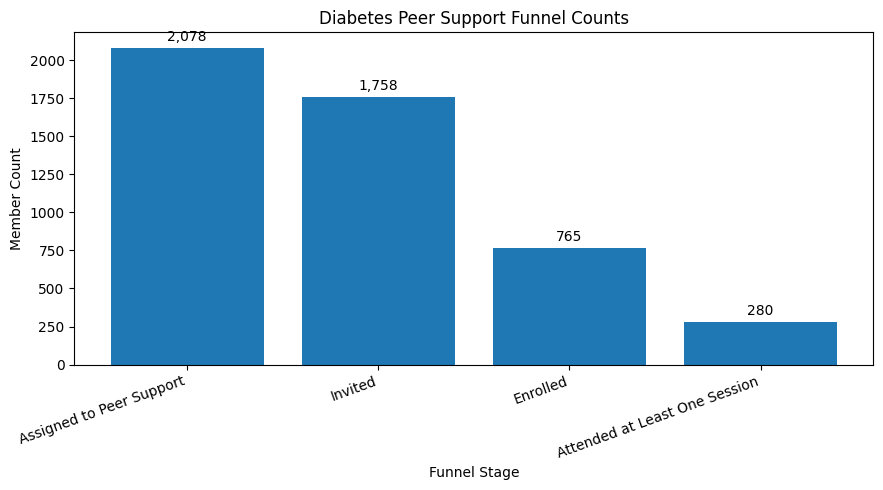

In [11]:
# Visualize member counts across the peer-support funnel
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    funnel_summary["funnel_stage"],
    funnel_summary["member_count"]
)

# Add count labels above bars
for bar in bars:
    height = bar.get_height()
    ax.annotate(
        f"{height:,.0f}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        va="bottom"
    )

ax.set_title("Diabetes Peer Support Funnel Counts")
ax.set_xlabel("Funnel Stage")
ax.set_ylabel("Member Count")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## 12. Funnel Rate Visualization

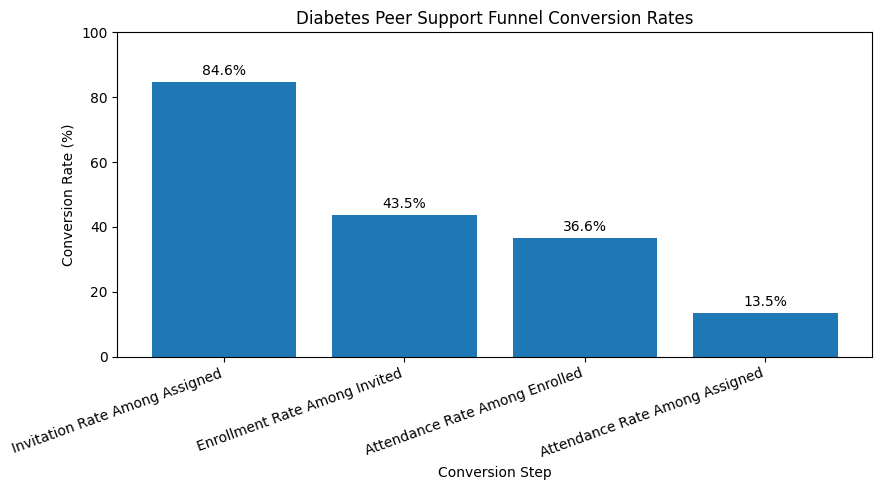

In [12]:
# Visualize stage-to-stage conversion rates as percentages
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    funnel_conversion_summary["conversion_step"],
    funnel_conversion_summary["conversion_rate_pct"]
)

# Add percentage labels above bars
for bar in bars:
    height = bar.get_height()
    ax.annotate(
        f"{height:.1f}%",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        va="bottom"
    )

ax.set_title("Diabetes Peer Support Funnel Conversion Rates")
ax.set_xlabel("Conversion Step")
ax.set_ylabel("Conversion Rate (%)")
ax.set_ylim(0, 100)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## 13. Funnel Findings

The peer-support funnel shows how members moved from assignment to invitation, enrollment, and attendance.

Key funnel results:

- Assigned to Diabetes Peer Support: 2,078 members
- Invited: 1,758 members
- Enrolled: 765 members
- Attended at least one session: 280 members

The largest drop-off by member count occurred between invitation and enrollment, while the highest stage-to-stage drop-off rate occurred between enrollment and attendance.

- Invited members: 1,758
- Enrolled members: 765
- Drop-off: 993 members

This suggests that the biggest implementation bottleneck may be converting invited members into enrolled participants.

A second important drop-off occurs between enrollment and first-session attendance. Even after enrollment, only a subset of members attended at least one session.

Possible operational explanations include scheduling friction, transportation barriers, weak follow-up after enrollment, limited perceived value, or outreach fatigue.

These findings should be interpreted as operational funnel insights, not causal treatment-effect estimates.

## 14. Session Attendance Distribution

Next, we examine how many peer-support sessions treatment members attended.

This helps distinguish between simple program exposure and deeper program engagement.

## 15. Session Count Distribution

In [13]:
# Count how many treatment members attended each number of sessions
session_distribution = (
    treatment["sessions_attended_count"]
    .value_counts()
    .sort_index()
    .reset_index()
)

# Rename columns for readability
session_distribution.columns = ["sessions_attended_count", "member_count"]

# Calculate each session count's share of the treatment group
session_distribution["pct_of_treatment"] = (
    session_distribution["member_count"] / len(treatment) * 100
)

# Round the percentage column for easier interpretation
session_distribution["pct_of_treatment"] = session_distribution["pct_of_treatment"].round(1)

session_distribution

,sessions_attended_count,member_count,pct_of_treatment
0,0,1802,86.7
1,1,33,1.6
2,2,46,2.2
3,3,61,2.9
4,4,52,2.5
5,5,33,1.6
6,6,28,1.3
7,7,8,0.4
8,8,15,0.7


## 16. Session Distribution Visualization

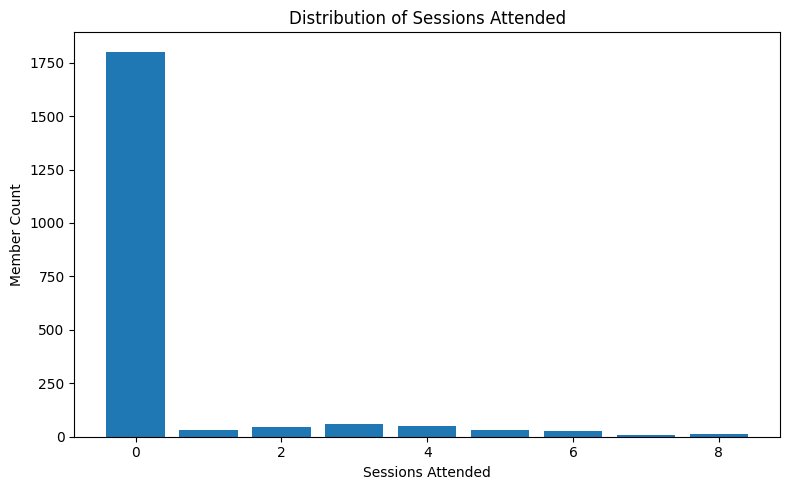

In [14]:
# Visualize the distribution of session attendance among treatment members
plt.figure(figsize=(8, 5))
plt.bar(
    session_distribution["sessions_attended_count"],
    session_distribution["member_count"]
)

plt.title("Distribution of Sessions Attended")
plt.xlabel("Sessions Attended")
plt.ylabel("Member Count")
plt.tight_layout()
plt.show() 




## 17. Create Attendance Groups

In [15]:
# Convert raw session counts into business-friendly Attendance groups
def categorize_attendance(session_count):
    if session_count == 0:
        return "0 sessions"
    elif session_count == 1:
        return "1 session"
    elif session_count in [2, 3]:
        return "2-3 sessions"
    else:
        return "4+ sessions"

# Apply the attendance grouping to treatment members only
treatment["attendance_group"] = treatment["sessions_attended_count"].apply(categorize_attendance)

# Check the size of each attendance group
treatment["attendance_group"].value_counts()

attendance_group
0 sessions      1802
4+ sessions      136
2-3 sessions     107
1 session         33
Name: count, dtype: int64

## 18. Attendance Group Order

In [16]:
# Define a logical order for attendance groups
attendance_order = ["0 sessions", "1 session", "2-3 sessions", "4+ sessions"]

# Store the attendance group as an ordered categorical variable 
treatment["attendance_group"] = pd.Categorical(
        treatment["attendance_group"],
        categories=attendance_order,
        ordered=True 
    )


## 19. Compliance by Attendance Group

In [17]:
# Summarize diabetes testing outcomes by attendance group
attendance_summary = (
    treatment.groupby("attendance_group", observed=True)
    .agg(
        members=("member_id", "count"),
        avg_compliance_rate=("diabetes_testing_compliance_rate", "mean"),
        binary_compliance_rate=("diabetes_testing_compliant", "mean"),
        avg_baseline_engagement=("baseline_engagement_score", "mean"),
        avg_sdoh_risk=("sdoh_risk_score", "mean"),
        avg_prior_testing_compliance=("prior_testing_compliance_rate", "mean")
    ).reset_index() 
)

# Convert outcome rates to percentages for easier interpretation
attendance_summary["avg_compliance_rate_pct"] = (
    attendance_summary["avg_compliance_rate"] * 100
)

attendance_summary["binary_compliance_rate_pct"] = (
    attendance_summary["binary_compliance_rate"] * 100
)

# Round numeric columns for readability
attendance_summary = attendance_summary.round({
    "avg_compliance_rate" : 3,
    "binary_compliance_rate": 3,
    "avg_baseline_engagement": 2,
    "avg_sdoh_risk": 2,
    "avg_prior_testing_compliance": 3,
    "avg_compliance_rate_pct": 1,
    "binary_compliance_rate_pct": 1
})

attendance_summary


,attendance_group,members,avg_compliance_rate,binary_compliance_rate,avg_baseline_engagement,avg_sdoh_risk,avg_prior_testing_compliance,avg_compliance_rate_pct,binary_compliance_rate_pct
0,0 sessions,1802,0.731,0.397,0.51,0.34,0.599,73.1,39.7
1,1 session,33,0.818,0.545,0.55,0.28,0.593,81.8,54.5
2,2-3 sessions,107,0.813,0.561,0.51,0.29,0.584,81.3,56.1
3,4+ sessions,136,0.848,0.625,0.60,0.29,0.629,84.8,62.5


## 20. Compliance Rate By Attendance Group Visualization

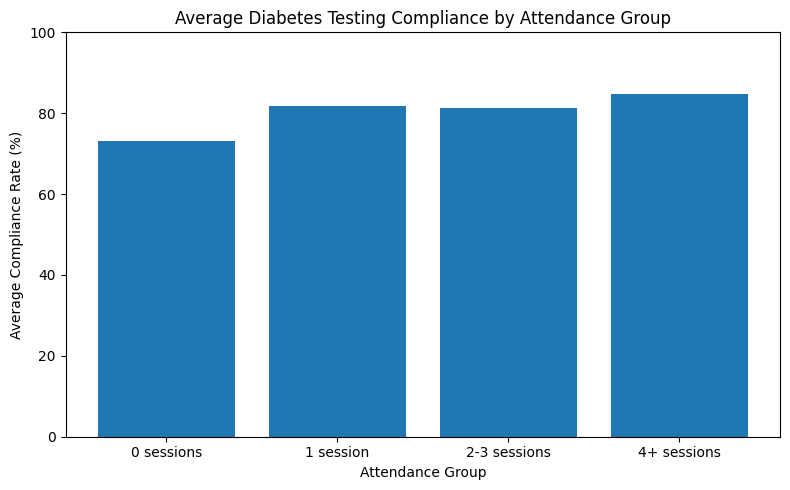

In [18]:
# Visualize average testing compliance by attendance group
plt.figure(figsize=(8,5))
plt.bar(
    attendance_summary["attendance_group"].astype(str),
    attendance_summary["avg_compliance_rate_pct"]
)

plt.title("Average Diabetes Testing Compliance by Attendance Group")
plt.xlabel("Attendance Group")
plt.ylabel("Average Compliance Rate (%)")
plt.ylim(0, 100)
plt.tight_layout()
plt.show() 

## 21. Binary Compliance by Attendance Group Visualization

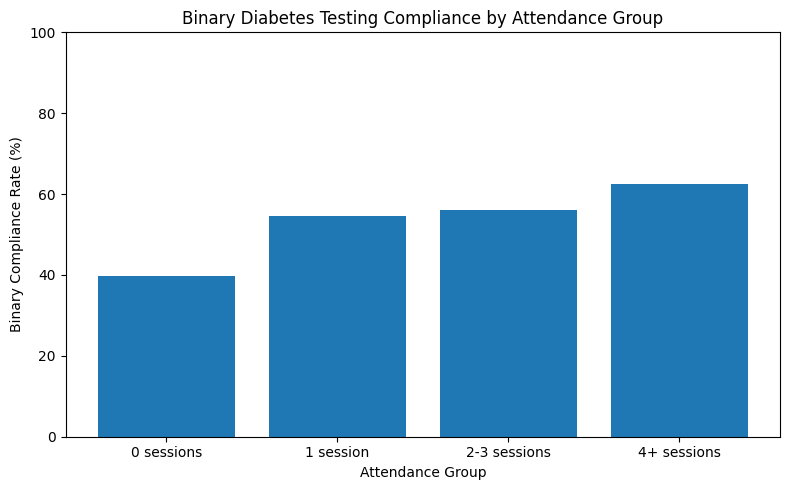

In [19]:
#  Visualize binary compliance rate by attendance group
plt.figure(figsize=(8,5))
plt.bar(
    attendance_summary["attendance_group"].astype(str),
    attendance_summary["binary_compliance_rate_pct"]
)

plt.title("Binary Diabetes Testing Compliance by Attendance Group")
plt.xlabel("Attendance Group")
plt.ylabel("Binary Compliance Rate (%)")
plt.ylim(0, 100)
plt.tight_layout()
plt.show() 

## 22. Important Causal Warning

The attendance comparison is not a randomized A/B test.

Members who attended more sessions may have had different baseline characteristics than members who attended no sessions. 

For example, they may have had: 

- higher baseline engagement,
- better access to transportation,
- higher health literacy,
- fewer SDOH barriers,
- stronger motivation to complete diabetes testing

Therefore, higher compliance among higher-attendance members should be interpreted as an association, not proof that additional sessions caused higher compliance.

In [20]:
# Check missingness in baseline variables used for attendance-group comparison
attendance_missingness_vars = [
    "baseline_engagement_score",
    "health_literacy_score"
]

attendance_missingness_summary = (
    treatment[attendance_missingness_vars]
    .isna()
    .mean()
    .mul(100)
    .reset_index()
)

attendance_missingness_summary.columns = [
    "baseline_variable",
    "missing_rate_pct"
]

attendance_missingness_summary.round(1)

,baseline_variable,missing_rate_pct
0,baseline_engagement_score,6.3
1,health_literacy_score,8.0


Baseline engagement and health literacy contain missing values.

Because these variables are used to compare attendance groups, missingness should be acknowledged when interpreting differences across session-attendance levels. This notebook treats the comparison as descriptive only.

A later adjusted analysis could use missingness indicators, imputation, or sensitivity checks to evaluate whether missing data meaningfully affects model-based conclusions.

## 23. Baseline Differences by Attendance Group

In [21]:
# Compare baseline characteristics across attendance groups to check for selection patterns
baseline_by_attendance = (
    treatment
    .groupby("attendance_group", observed=True)
    .agg(
        members=("member_id", "count"),
        avg_baseline_engagement=("baseline_engagement_score", "mean"),
        avg_health_literacy=("health_literacy_score", "mean"),
        avg_sdoh_risk=("sdoh_risk_score", "mean"),
        avg_prior_testing_compliance=("prior_testing_compliance_rate", "mean"),
        food_insecurity_rate=("food_insecurity", "mean"),
        transportation_barrier_rate=("transportation_barrier", "mean"),
        financial_barrier_rate=("financial_barrier", "mean"),
        housing_instability_rate=("housing_instability", "mean")
    )
    .reset_index()
)

# Convert barrier rates to percentages for business readability
barrier_rate_cols = [
    "food_insecurity_rate",
    "transportation_barrier_rate",
    "financial_barrier_rate",
    "housing_instability_rate"
]

baseline_by_attendance[barrier_rate_cols] = (
    baseline_by_attendance[barrier_rate_cols] * 100
)

# Round numeric columns for cleaner reporting
baseline_by_attendance = baseline_by_attendance.round({
    "avg_baseline_engagement": 2,
    "avg_health_literacy": 2,
    "avg_sdoh_risk": 2,
    "avg_prior_testing_compliance": 3,
    "food_insecurity_rate": 1,
    "transportation_barrier_rate": 1,
    "financial_barrier_rate": 1,
    "housing_instability_rate": 1
})

baseline_by_attendance

,attendance_group,members,avg_baseline_engagement,avg_health_literacy,avg_sdoh_risk,avg_prior_testing_compliance,food_insecurity_rate,transportation_barrier_rate,financial_barrier_rate,housing_instability_rate
0,0 sessions,1802,0.51,0.51,0.34,0.599,35.3,31.5,39.2,22.1
1,1 session,33,0.55,0.48,0.28,0.593,39.4,18.2,30.3,12.1
2,2-3 sessions,107,0.51,0.55,0.29,0.584,34.6,13.1,36.4,29.9
3,4+ sessions,136,0.60,0.54,0.29,0.629,34.6,22.8,34.6,20.6


## 24. Baseline Engagement Visualization

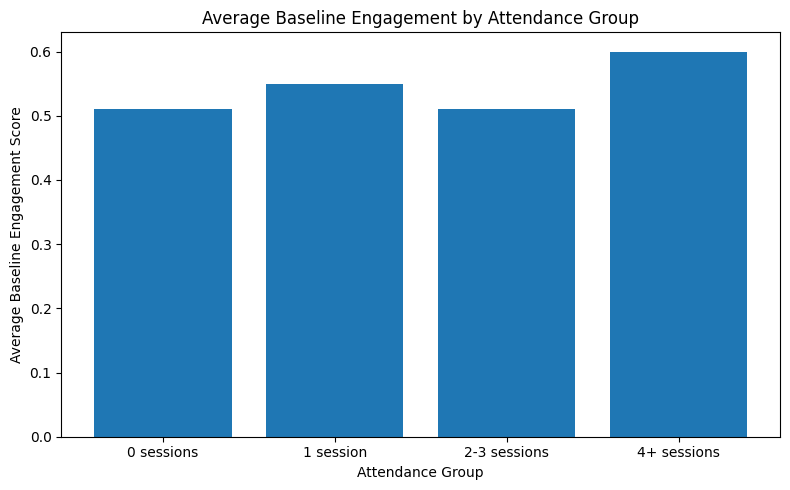

In [22]:
# Visualize whether baseline engagement differs across attendance groups
plt.figure(figsize=(8, 5))
plt.bar(
    baseline_by_attendance["attendance_group"].astype(str),
    baseline_by_attendance["avg_baseline_engagement"]
)

plt.title("Average Baseline Engagement by Attendance Group")
plt.xlabel("Attendance Group")
plt.ylabel("Average Baseline Engagement Score")
plt.tight_layout()
plt.show()

## 25. SDOH Risk Visualization

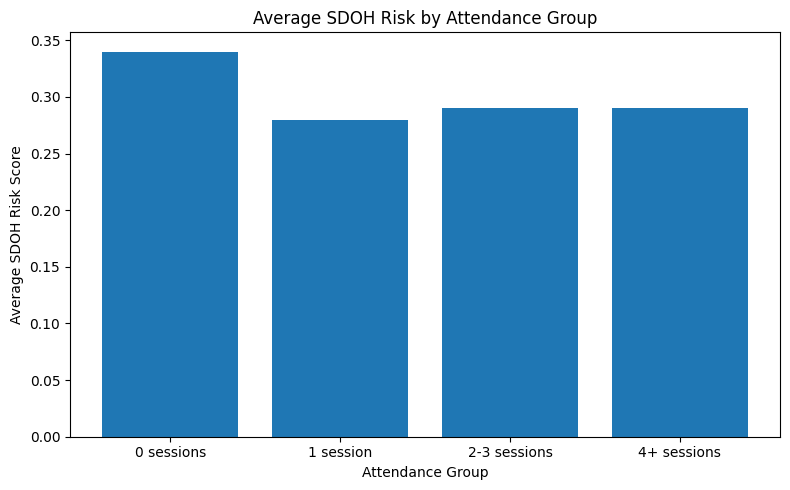

In [23]:
# Visualize whether SDOH risk differs across attendance groups
plt.figure(figsize=(8, 5))
plt.bar(
    baseline_by_attendance["attendance_group"].astype(str),
    baseline_by_attendance["avg_sdoh_risk"]
)

plt.title("Average SDOH Risk by Attendance Group")
plt.xlabel("Attendance Group")
plt.ylabel("Average SDOH Risk Score")
plt.tight_layout()
plt.show()

## 26. Correlation Check

In [24]:
# Check simple correlations between attendance, outcomes, and baseline traits
correlation_cols = [
    "sessions_attended_count",
    "diabetes_testing_compliance_rate",
    "baseline_engagement_score",
    "health_literacy_score",
    "sdoh_risk_score",
    "prior_testing_compliance_rate"
]

# Correlation is exploratory and should not be interpreted causally
treatment[correlation_cols].corr().round(3)

,sessions_attended_count,diabetes_testing_compliance_rate,baseline_engagement_score,health_literacy_score,sdoh_risk_score,prior_testing_compliance_rate
sessions_attended_count,1.000,0.122,0.102,0.030,-0.060,0.030
diabetes_testing_compliance_rate,0.122,1.000,0.241,0.144,-0.184,0.191
baseline_engagement_score,0.102,0.241,1.000,0.010,-0.012,0.249
health_literacy_score,0.030,0.144,0.010,1.000,-0.019,0.134
sdoh_risk_score,-0.060,-0.184,-0.012,-0.019,1.000,-0.217
prior_testing_compliance_rate,0.030,0.191,0.249,0.134,-0.217,1.000


## 27. Attendance Findings

Members with higher session attendance generally had higher diabetes testing compliance than members who attended no sessions.

However, this relationship should be interpreted carefully. Session attendance is not randomly assigned. Members who attend more sessions may differ from non-attendees in baseline engagement, health literacy, transportation access, SDOH risk, or unobserved motivation.

Therefore, this notebook shows an association between attendance and compliance, not proof that higher attendance caused higher compliance.

The safest interpretation is:

Higher peer-support attendance is associated with better diabetes testing compliance, but the result may partly reflect selection bias.

## 28. Business Interpretation

The peer-support funnel analysis helps identify whether the program is operationally scalable.

If the main drop-off occurs before enrollment, the program may need better outreach messaging, simpler enrollment workflows, or stronger provider/care-manager referrals.

If the main drop-off occurs after enrollment but before attendance, the program may need reminder calls, easier scheduling, transportation support, virtual options, or language-matched peer leaders.

If members who attend more sessions show better compliance, the program team should treat session attendance as a useful engagement signal. However, this should support operational targeting, not causal claims.

The main randomized evidence still comes from the intent-to-treat A/B test in Notebook 02.

## 29. Summary

This notebook evaluated the Diabetes Peer Support operational funnel.

Key takeaways:

1. The funnel structure was valid, with no detected logical violations.
2. Members moved through assignment, invitation, enrollment, and attendance stages.
3. Funnel conversion rates identified where program drop-off occurred.
4. Session attendance varied across treatment members.
5. Higher attendance was explored as an operational engagement signal.
6. Attendance-based comparisons are not causal because members self-select into participation.

The randomized treatment effect remains the intent-to-treat result from Notebook 02. This notebook explains program implementation, engagement, and possible operational bottlenecks.